<a href="https://colab.research.google.com/github/tejalkv0/simple-project-using-RNN/blob/main/GRU_and_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using: cuda
Characters: 1115394 | Vocab: 65
LSTM step 0: loss 4.157
LSTM step 300: loss 1.640
LSTM step 600: loss 1.470
LSTM step 900: loss 1.389
LSTM step 1200: loss 1.395
LSTM finished in 47s, final loss 1.312

GRU step 0: loss 4.175
GRU step 300: loss 1.517
GRU step 600: loss 1.378
GRU step 900: loss 1.344
GRU step 1200: loss 1.300
GRU finished in 42s, final loss 1.277

==================== LSTM output ====================
ROMEO:
Fetch thee, of my Nather, you can in my prison.

SICINIUS:
Well, he is nothing to his moral day;
Nor are written under doth make me for him:
And yet it she shall bold the king and mother,
To last the aich most thing in these fellows,
Once the pinity of good to the heads show you.
What sometime is marched again?

Provost:
I prithee for my master.

SICINIUS:
What, brother we have spited with in his 

==================== GRU output ====================
ROMEO:
That would I would to inform thee in hope,
That we being some foot of sight, repreviness
And see the 

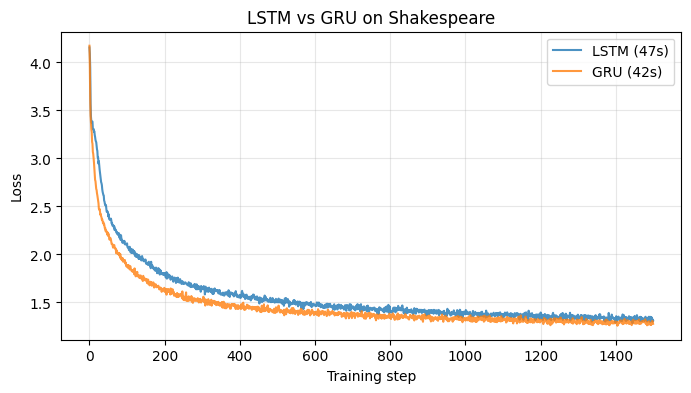

Parameters  LSTM: 946625 | GRU: 716225


In [ ]:
import torch, torch.nn as nn, urllib.request, time
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

# 1. Data: Tiny Shakespeare
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urllib.request.urlopen(url).read().decode("utf-8")
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
vocab = len(chars)
print("Characters:", len(text), "| Vocab:", vocab)

seq_len, batch = 100, 128
def get_batch():
    ix = torch.randint(len(data) - seq_len - 1, (batch,))
    x = torch.stack([data[i:i + seq_len] for i in ix])
    y = torch.stack([data[i + 1:i + seq_len + 1] for i in ix])
    return x.to(device), y.to(device)

# 2. Model: same code for LSTM and GRU
class CharRNN(nn.Module):
    def __init__(self, kind, vocab, emb=128, hid=256, layers=2):
        super().__init__()
        rnn = nn.LSTM if kind == "LSTM" else nn.GRU
        self.emb = nn.Embedding(vocab, emb)
        self.rnn = rnn(emb, hid, layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hid, vocab)
    def forward(self, x, h=None):
        o, h = self.rnn(self.emb(x), h)
        return self.fc(o), h

# 3. Train
def train(kind, steps=1500):
    model = CharRNN(kind, vocab).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-3)
    loss_fn = nn.CrossEntropyLoss()
    losses, start = [], time.time()
    for step in range(steps):
        x, y = get_batch()
        out, _ = model(x)
        loss = loss_fn(out.reshape(-1, vocab), y.reshape(-1))
        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        losses.append(loss.item())
        if step % 300 == 0:
            print(f"{kind} step {step}: loss {loss.item():.3f}")
    secs = time.time() - start
    print(f"{kind} finished in {secs:.0f}s, final loss {losses[-1]:.3f}\n")
    return model, losses, secs

# 4. Generate text
@torch.no_grad()
def generate(model, prompt="ROMEO:\n", length=400, temp=0.8):
    model.eval()
    x = torch.tensor([[stoi[c] for c in prompt]], device=device)
    out, h = model(x)
    result = prompt
    for _ in range(length):
        probs = torch.softmax(out[:, -1] / temp, dim=-1)
        nxt = torch.multinomial(probs, 1)
        result += itos[nxt.item()]
        out, h = model(nxt, h)
    return result

# 5. Run both and compare
results = {}
for kind in ["LSTM", "GRU"]:
    results[kind] = train(kind)

for kind, (model, _, _) in results.items():
    print("=" * 20, kind, "output", "=" * 20)
    print(generate(model))
    print()

plt.figure(figsize=(8, 4))
for kind, (_, losses, secs) in results.items():
    plt.plot(losses, label=f"{kind} ({secs:.0f}s)", alpha=0.8)
plt.xlabel("Training step"); plt.ylabel("Loss")
plt.title("LSTM vs GRU on Shakespeare"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("Parameters  LSTM:", sum(p.numel() for p in results["LSTM"][0].parameters()),
      "| GRU:", sum(p.numel() for p in results["GRU"][0].parameters()))